In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

--- توزيع عدد مرات ظهور المنتج (total_orders) ---
count     49677.000000
mean        652.907563
std        4792.114416
min           1.000000
25%          17.000000
50%          60.000000
75%         260.000000
max      472565.000000
Name: total_orders, dtype: float64
0.50      60.00
0.75     260.00
0.90    1021.00
0.95    2286.00
0.99    9931.16
Name: total_orders, dtype: float64

عدد المنتجات قبل الفلترة: 49677
عدد المنتجات بعد فلترة (occurrences >= 1000): 5058

--- أعلى 20 منتج 'دائم' (بيتكرر شراؤه) ---
                               product_name  department  total_orders  \
9288        Half And Half Ultra Pasteurized  dairy eggs          2921   
45495            Whole Organic Omega 3 Milk  dairy eggs          9108   
43386       Organic Lactose Free Whole Milk  dairy eggs          8477   
5511         Organic Homogenized Whole Milk  dairy eggs          3970   
47220                  Ultra-Purified Water   beverages          1489   
29441              Milk, Organic, Vitamin D  dairy

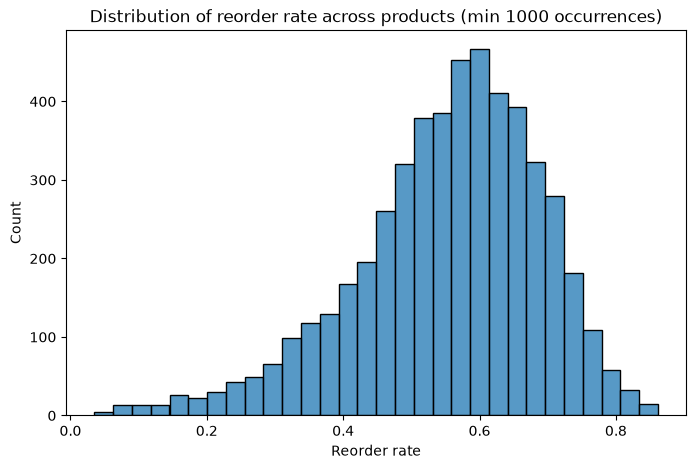

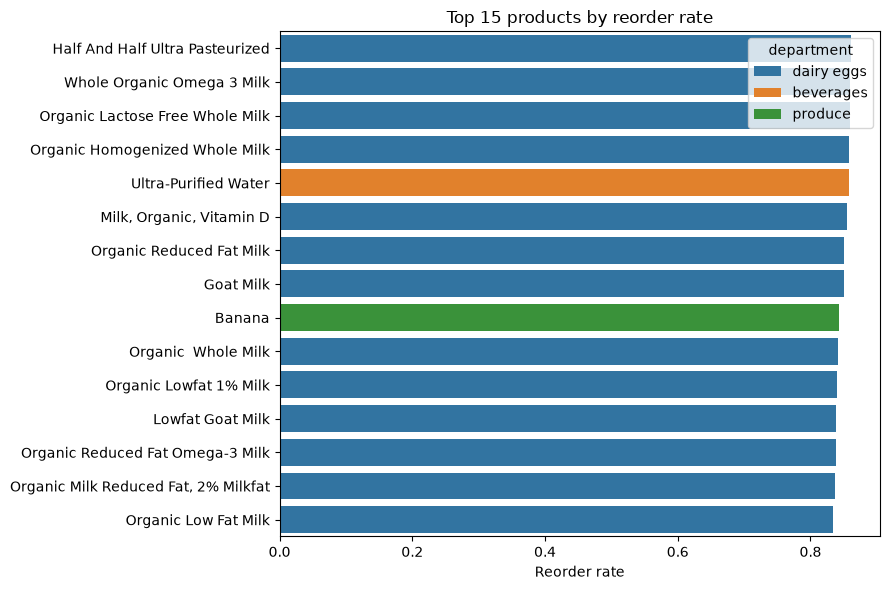


--- متوسط reorder rate لكل department ---
                 avg_reorder_rate  n_products
department                                   
dairy eggs               0.642467         827
beverages                0.635574         515
pets                     0.631508           6
bakery                   0.627268         262
other                    0.606827           3
alcohol                  0.598663          28
deli                     0.598341         201
babies                   0.593378         125
snacks                   0.584299         664
breakfast                0.569941         171
bulk                     0.556337           8
meat seafood             0.546886         117
frozen                   0.542937         476
produce                  0.541730         582
missing                  0.472019           8
dry goods pasta          0.464176         189
canned goods             0.449058         200
household                0.430537         165
personal care            0.404449    

In [8]:
# ============================================
# Widget 2: Reorder Rate بالـ Product
# ============================================

reorder_df = pd.read_parquet(
    '../data/instacart_cleaned_v1.parquet',
    columns=['product_id', 'product_name', 'aisle', 'department', 'reordered']
)

# reorder rate لكل منتج = عدد مرات reordered=1 / إجمالي عدد مرات ظهور المنتج
product_reorder = reorder_df.groupby(['product_id', 'product_name', 'department']).agg(
    total_orders=('reordered', 'count'),
    total_reorders=('reordered', 'sum')
).reset_index()

product_reorder['reorder_rate'] = product_reorder['total_reorders'] / product_reorder['total_orders']

# فحص توزيع total_orders عشان اختيار threshold سليم (مش عشوائي)
print("--- توزيع عدد مرات ظهور المنتج (total_orders) ---")
print(product_reorder['total_orders'].describe())
print(product_reorder['total_orders'].quantile([0.5, 0.75, 0.9, 0.95, 0.99]))

# threshold = قريب من الـ 90th percentile
# (جُرّب MIN_OCCURRENCES=50 الأول، ظهرت منتجات نادرة/غريبة متصدرة القايمة بسبب عينة صغيرة noisy
#  رفعنا الـ threshold لـ 1000 عشان نقتصر على منتجات عندها حجم عينة كافي نثق فيه)
MIN_OCCURRENCES = 1000
product_reorder_filtered = product_reorder[product_reorder['total_orders'] >= MIN_OCCURRENCES].copy()

print(f"\nعدد المنتجات قبل الفلترة: {len(product_reorder)}")
print(f"عدد المنتجات بعد فلترة (occurrences >= {MIN_OCCURRENCES}): {len(product_reorder_filtered)}")

# أعلى 20 منتج "دائم" (highest reorder rate)
top_loyal = product_reorder_filtered.sort_values('reorder_rate', ascending=False).head(20)
print("\n--- أعلى 20 منتج 'دائم' (بيتكرر شراؤه) ---")
print(top_loyal[['product_name', 'department', 'total_orders', 'reorder_rate']])

# أقل 20 منتج (يُشترى مرة واحدة غالبًا)
bottom_loyal = product_reorder_filtered.sort_values('reorder_rate', ascending=True).head(20)
print("\n--- أقل 20 منتج 'يُشترى مرة واحدة' ---")
print(bottom_loyal[['product_name', 'department', 'total_orders', 'reorder_rate']])

# رسمة: توزيع الـ reorder_rate عمومًا
plt.figure(figsize=(8, 5))
sns.histplot(product_reorder_filtered['reorder_rate'], bins=30)
plt.title(f'Distribution of reorder rate across products (min {MIN_OCCURRENCES} occurrences)')
plt.xlabel('Reorder rate')
plt.show()

# رسمة: أعلى 15 منتج بار تشارت
plt.figure(figsize=(9, 6))
sns.barplot(data=top_loyal.head(15), y='product_name', x='reorder_rate', hue='department', dodge=False)
plt.title('Top 15 products by reorder rate')
plt.xlabel('Reorder rate')
plt.ylabel('')
plt.tight_layout()
plt.show()

# تحقق: هل السيطرة الظاهرة لـ dairy eggs في الأعلى حقيقية ولا مجرد bias لحجم الـ department؟
department_reorder = product_reorder_filtered.groupby('department').agg(
    avg_reorder_rate=('reorder_rate', 'mean'),
    n_products=('product_id', 'count')
).sort_values('avg_reorder_rate', ascending=False)

print("\n--- متوسط reorder rate لكل department ---")
print(department_reorder)

--- Peak hour لكل department ---
          department  order_hour_of_day  pct_of_dept
33            babies                  9     8.130212
58            bakery                 10     8.383590
82         beverages                 10     9.113727
106        breakfast                 10     8.877079
178       dairy eggs                 10     8.691312
130             bulk                 10     8.926041
346          missing                 10     8.509654
274        household                 10     8.671578
466          produce                 10     8.442045
490           snacks                 10     9.106890
418    personal care                 10     8.294138
203             deli                 11     8.498557
395           pantry                 11     8.606258
155     canned goods                 11     8.710388
374            other                 14     8.365711
230  dry goods pasta                 14     8.548199
303    international                 15     8.622002
327     meat 

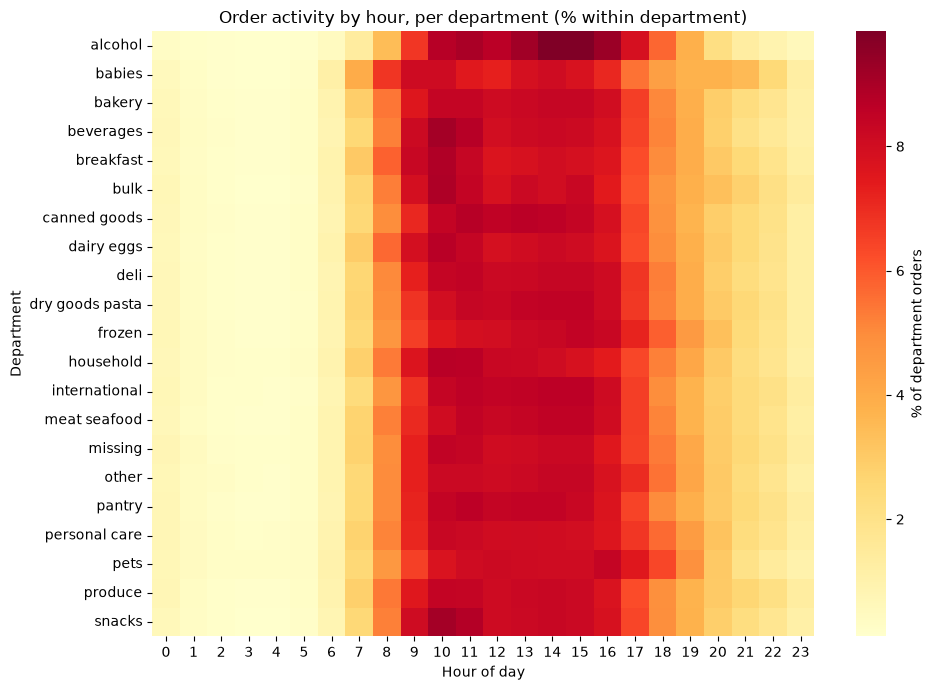

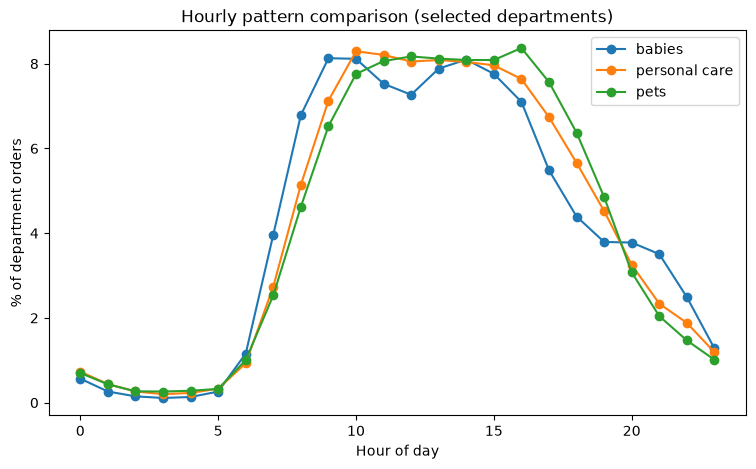

In [10]:
# ============================================
# Widget 3: Peak Hour لكل Department
# ============================================

peak_df = pd.read_parquet(
    '../data/instacart_cleaned_v1.parquet',
    columns=['order_id', 'department', 'order_hour_of_day']
)

orders_by_hour_dept = peak_df.groupby(['department', 'order_hour_of_day']).size().reset_index(name='order_count')

# نسبة كل ساعة من إجمالي الديبارتمنت (عشان نقارن الأنماط مش الأحجام المطلقة)
orders_by_hour_dept['pct_of_dept'] = orders_by_hour_dept.groupby('department')['order_count'].transform(
    lambda x: x / x.sum() * 100
)

# الساعة اللي فيها أعلى نشاط لكل department
peak_hour_per_dept = orders_by_hour_dept.loc[
    orders_by_hour_dept.groupby('department')['order_count'].idxmax()
][['department', 'order_hour_of_day', 'pct_of_dept']].sort_values('order_hour_of_day')

print("--- Peak hour لكل department ---")
print(peak_hour_per_dept)

# رسمة: heatmap لكل الديبارتمنتس عبر الساعات
pivot = orders_by_hour_dept.pivot(index='department', columns='order_hour_of_day', values='pct_of_dept')
plt.figure(figsize=(10, 7))
sns.heatmap(pivot, cmap='YlOrRd', cbar_kws={'label': '% of department orders'})
plt.title('Order activity by hour, per department (% within department)')
plt.xlabel('Hour of day')
plt.ylabel('Department')
plt.tight_layout()
plt.show()

# رسمة: مقارنة أنماط بين 3 ديبارتمنتس مختلفة
sample_depts = peak_hour_per_dept.sort_values('order_hour_of_day')['department'].tolist()
sample_depts = [sample_depts[0], sample_depts[len(sample_depts)//2], sample_depts[-1]]

plt.figure(figsize=(9, 5))
for dept in sample_depts:
    subset = orders_by_hour_dept[orders_by_hour_dept['department'] == dept]
    plt.plot(subset['order_hour_of_day'], subset['pct_of_dept'], marker='o', label=dept)
plt.title('Hourly pattern comparison (selected departments)')
plt.xlabel('Hour of day')
plt.ylabel('% of department orders')
plt.legend()
plt.show()

--- إحصائيات حجم السلة ---
count    3.214874e+06
mean     1.008888e+01
std      7.525398e+00
min      1.000000e+00
25%      5.000000e+00
50%      8.000000e+00
75%      1.400000e+01
max      1.450000e+02
Name: basket_size, dtype: float64
0.50     8.0
0.90    20.0
0.95    25.0
0.99    35.0
Name: basket_size, dtype: float64


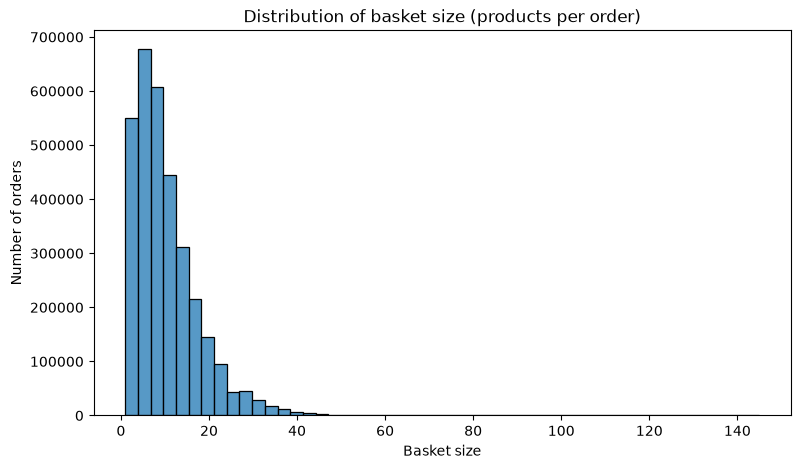

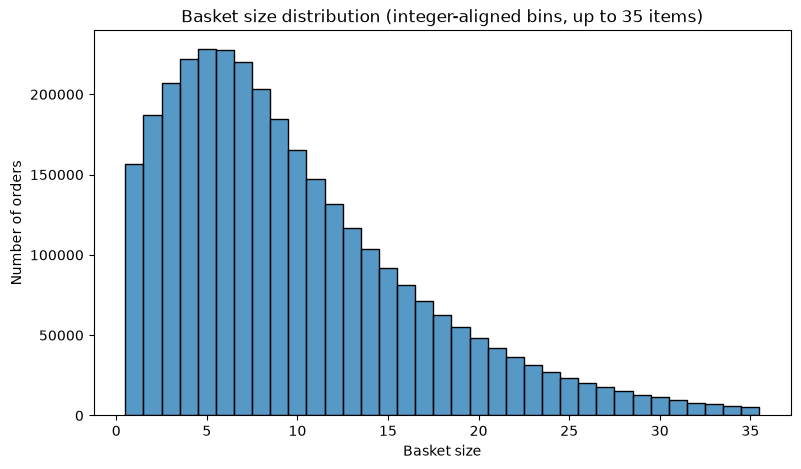

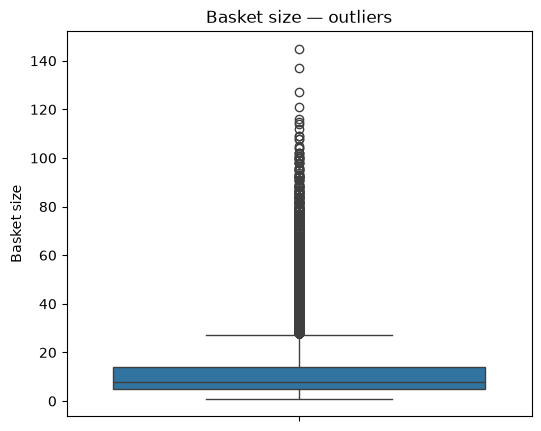

In [14]:
# ============================================
# Widget 4: Basket Size Distribution
# ============================================

basket_df = pd.read_parquet(
    '../data/instacart_cleaned_v1.parquet',
    columns=['order_id', 'product_id']
)

basket_size = basket_df.groupby('order_id')['product_id'].count().reset_index(name='basket_size')

print("--- إحصائيات حجم السلة ---")
print(basket_size['basket_size'].describe())
print(basket_size['basket_size'].quantile([0.5, 0.9, 0.95, 0.99]))

# رسمة 1: توزيع حجم السلة (كامل)
plt.figure(figsize=(9, 5))
sns.histplot(basket_size['basket_size'], bins=50)
plt.title('Distribution of basket size (products per order)')
plt.xlabel('Basket size')
plt.ylabel('Number of orders')
plt.show()

# رسمة 2: zoomed-in على المدى الشائع (بيتشال الـ tail الطويل عشان الرسمة تبقى مقروءة)
# استخدم bins محاذية للأعداد الصحيحة بدل bins=40 عشوائي
plt.figure(figsize=(9, 5))
sns.histplot(basket_size[basket_size['basket_size'] <= p99]['basket_size'], 
             bins=range(1, int(p99)+2), discrete=True)
plt.title(f'Basket size distribution (integer-aligned bins, up to {p99:.0f} items)')
plt.xlabel('Basket size')
plt.ylabel('Number of orders')
plt.show()

# رسمة 3: boxplot عام (يوريك الـ outliers - أوردرات بعدد منتجات ضخم جدًا)
plt.figure(figsize=(6, 5))
sns.boxplot(y=basket_size['basket_size'])
plt.title('Basket size — outliers')
plt.ylabel('Basket size')
plt.show()


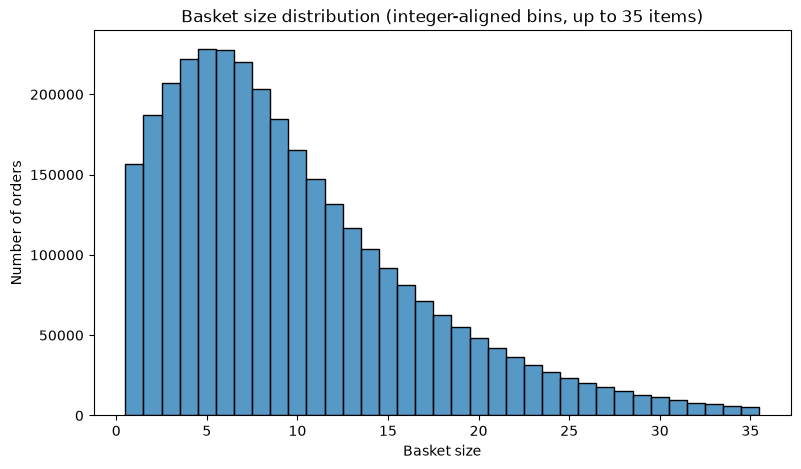

In [13]:
# استخدم bins محاذية للأعداد الصحيحة بدل bins=40 عشوائي
plt.figure(figsize=(9, 5))
sns.histplot(basket_size[basket_size['basket_size'] <= p99]['basket_size'], 
             bins=range(1, int(p99)+2), discrete=True)
plt.title(f'Basket size distribution (integer-aligned bins, up to {p99:.0f} items)')
plt.xlabel('Basket size')
plt.ylabel('Number of orders')
plt.show()

In [15]:
import os
os.makedirs('../data/processed', exist_ok=True)

product_reorder_filtered.to_parquet('../data/processed/reorder_products.parquet', index=False)
department_reorder.reset_index().to_parquet('../data/processed/department_reorder.parquet', index=False)
peak_hour_per_dept.to_parquet('../data/processed/peak_hours.parquet', index=False)
basket_size.to_parquet('../data/processed/basket_size.parquet', index=False)
print("✅ saved reorder_products / department_reorder / peak_hours / basket_size")

✅ saved reorder_products / department_reorder / peak_hours / basket_size
